<img align="center" src="https://iili.io/3wI8gI.png" style="height:90px" style="width:30px"/>

# Group By | Titanic

Import pandas and read the `titanic.csv` file

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("titanic.csv")

In [5]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
0,0,3,male,22.0,1,0,7.2500,S,NaN
1,1,1,female,38.0,1,0,71.2833,C,C
2,1,3,female,26.0,0,0,7.9250,S,NaN
3,1,1,female,35.0,1,0,53.1000,S,C
4,0,3,male,35.0,0,0,8.0500,S,NaN


## titanic Q1

How big is the difference between the mean fare price for third class compared with the most expensive ticket in third class

In [8]:
int(df.loc[df["pclass"] == 3]["fare"].max()) - int(df.loc[df["pclass"] == 3]["fare"].mean())

56

## titanic Q2

On average, how much older were the men in first class compared to the women in first class?

In [11]:
int(df.loc[(df["pclass"] == 3) & (df["sex"] == "male")]["age"].mean()) - int(df.loc[(df["pclass"] == 3) & (df["sex"] == "female")]["age"].mean())

5

## titanic Q3

Use `pd.qcut()` to create 4 age categories based off the age column. Store the 4 age categories in a new column named `age_cat`

Group by `age_cat` and `gender` and answer the following 2 questions: 
- which group had the highest survival rate?
- which group had the lowest survival rate?


In [13]:
df["age_cat"] = pd.qcut(df["age"],q=4,labels=["cat_1","cat_2","cat_3","cat_4"])


In [18]:
df.groupby("age_cat")["survived"].mean().sort_values()

age_cat
cat_2    0.360656
cat_4    0.372881
cat_3    0.434286
cat_1    0.458101
Name: survived, dtype: float64

## titanic Q4

Group by pclass and sex and calculate the survival rate for each group. Plot the results

In [26]:
df.groupby(["sex","pclass"])["survived"].mean().unstack()

pclass,1,2,3
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [27]:
import seaborn as sns

<Axes: xlabel='sex'>

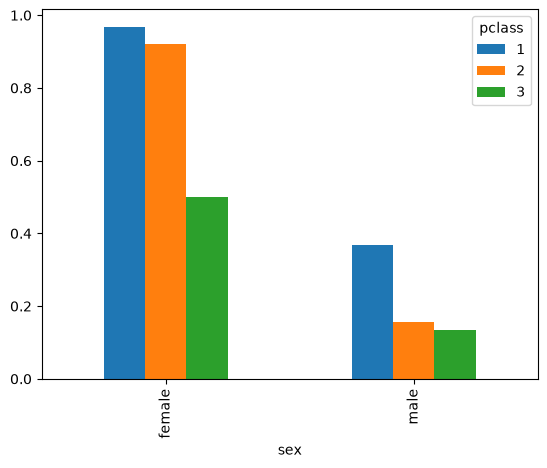

In [31]:
df.groupby(["sex","pclass"])["survived"].mean().unstack().plot(kind="bar")

# Group By | `ramen`

Read the file `ramen.csv`

Now filter the df, it should only contain rows from the:
- top 10 most frequent brands
- top 4 most frequent styles
- top 10 most frequent countries

*After filtering your df should contain 820 rows* 

In [51]:
df2 = pd.read_csv("ramen.csv")
df_copy = df2.copy()

In [58]:
top_brands = df2["Brand"].value_counts().head(10).index
top_styles = df2["Style"].value_counts().head(4).index
top_countries = df2["Country"].value_counts().head(10).index

df_copy = df2[df2["Brand"].isin(top_brands) & df2["Style"].isin(top_styles) & df2["Country"].isin(top_countries)]

In [60]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 820 entries, 2 to 2555
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Brand    820 non-null    str    
 1   Variety  820 non-null    str    
 2   Style    820 non-null    str    
 3   Country  820 non-null    str    
 4   Stars    820 non-null    float64
 5   Top Ten  16 non-null     str    
dtypes: float64(1), str(5)
memory usage: 44.8 KB


In [ ]:
df2["Brand"].value_counts().iloc[:10]

In [61]:
df_copy

,Brand,Variety,Style,Country,Stars,Top Ten
2,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,NaN
5,Samyang Foods,Kimchi song Song Ramen,Pack,South Korea,4.75,NaN
12,Nongshim,Mr. Bibim Stir-Fried Kimchi Flavor,Pack,South Korea,4.25,NaN
13,Nissin,Deka Buto Kimchi Pork Flavor,Bowl,Japan,4.50,NaN
14,Nissin,Demae Ramen Bar Noodle Aka Tonkotsu Flavour In...,Pack,Hong Kong,5.00,NaN
...,...,...,...,...,...,...
2551,Nongshim,Ansungtangmyun Noodle Soup,Pack,South Korea,3.75,NaN
2552,Nongshim,Champong Oriental Noodles,Pack,South Korea,4.00,NaN
2553,Nongshim,Neoguri (Seafood'n'Spicy),Pack,South Korea,3.50,NaN
2554,Nongshim,Shin Ramyun,Pack,South Korea,4.00,NaN


## ramen Q1 

Which country has the highest rating?

In [66]:
df_copy[["Country","Stars"]].groupby("Country").mean().sort_values(by="Stars",ascending=False)


,Stars
Country,
Hong Kong,4.141791
Singapore,4.093023
Indonesia,4.076923
Japan,4.075702
South Korea,3.897619
China,3.687500
Thailand,3.605333
USA,3.586230


## ramen Q2

What Style has the highest rating in China?

In [84]:
df_copy.loc[df_copy["Country"] == "China"][["Style","Stars","Country"]].groupby(["Style","Country"]).mean().sort_values(by="Stars",ascending=False).reset_index()

,Style,Country,Stars
0,Pack,China,4.7500
1,Cup,China,3.5625
2,Bowl,China,2.8750


## ramen Q3

What is the brand with the highest rating in:
- Japan?
- South Korea?
- Indonesia?

In [97]:
df_copy.loc[df_copy["Country"].isin(["Japan","Indonesia","South Korea"])] \
[["Country","Brand","Stars"]] \
.groupby(["Country","Brand"])  \
.mean() \
.sort_values(by="Stars",ascending=False)  \
.groupby("Country") \
.head(1) \
.reset_index() 

,Country,Brand,Stars
0,Japan,Nissin,4.259910
1,South Korea,Samyang Foods,4.102041
2,Indonesia,Indomie,4.085000


,Country,Brand,Stars
0,Japan,Nissin,4.259910
1,South Korea,Samyang Foods,4.102041
2,Indonesia,Indomie,4.085000


# Group By | Cuisines

read the file `Cuisine_rating.csv`

In [98]:
df = pd.read_csv("Cuisine_rating.csv")

## Q1
- What is the most popular `Cuisines` in this dataset? <br>
- __Bonus:__ Order by values and plot it (bar plot).

<Axes: xlabel='Cuisines'>

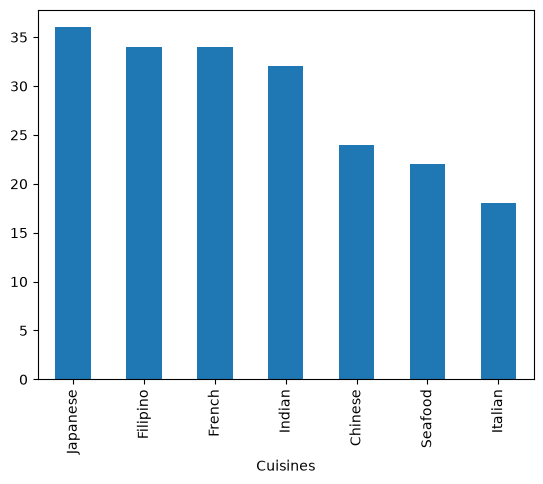

In [104]:
df["Cuisines"].value_counts().plot(kind="bar")

In [102]:
df.groupby(by="Cuisines").count()

,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
Cuisines,,,,,,,,,,,,,,
Chinese,24,24,24,24,24,24,24,24,24,24,24,24,24,24
Filipino,34,34,34,34,34,34,34,34,34,34,34,34,34,34
French,34,34,34,34,34,34,34,34,34,34,34,34,34,34
Indian,32,32,32,32,32,32,32,32,32,32,32,32,32,32
Italian,18,18,18,18,18,18,18,18,18,18,18,18,18,18
Japanese,36,36,36,36,36,36,36,36,36,36,36,36,36,36
Seafood,22,22,22,22,22,22,22,22,22,22,22,22,22,22


## Q 2
What is men's favorite cuisines?<br>
What is women's?<br>
__Bonus__ plot it using pie chart

In [116]:
df.head()


,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
0,1,153,"Upper East Side,NY",Female,2006,Single,Professional,3,Japanese,Never,Never,5,4,4.5,No
1,2,123,"St. George,NY",Female,1991,Married,Student,3,Indian,Never,Socially,1,1,1.0,No
2,3,122,"Upper West Side,NY",Male,1977,Single,Student,5,Seafood,Often,Often,5,5,5.0,Yes
3,4,153,"Upper East Side,NY",Female,1956,Married,Professional,5,Japanese,Never,Socially,3,1,2.0,No
4,5,129,"Central Park,NY",Male,1997,Single,Student,4,Filipino,Socially,Never,2,4,3.0,No


In [124]:
df[["Gender","Food Rating","Cuisines"]].groupby(["Gender","Cuisines"]).mean().sort_values(by="Food Rating",ascending=False).groupby("Gender").head(1).reset_index()

,Gender,Cuisines,Food Rating
0,Female,Japanese,4.071429
1,Male,Japanese,3.727273


## Q3
Which `Martial Status` is the most prevalent in the users who ate Japanese food

In [118]:
df.loc[df["Cuisines"] == "Japanese"]["Marital Status"].value_counts()

Marital Status
Single      22
Married     10
Divorced     4
Name: count, dtype: int64

__Bonus__ plot it (Bar plot)

In [120]:
df.head()

,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
0,1,153,"Upper East Side,NY",Female,2006,Single,Professional,3,Japanese,Never,Never,5,4,4.5,No
1,2,123,"St. George,NY",Female,1991,Married,Student,3,Indian,Never,Socially,1,1,1.0,No
2,3,122,"Upper West Side,NY",Male,1977,Single,Student,5,Seafood,Often,Often,5,5,5.0,Yes
3,4,153,"Upper East Side,NY",Female,1956,Married,Professional,5,Japanese,Never,Socially,3,1,2.0,No
4,5,129,"Central Park,NY",Male,1997,Single,Student,4,Filipino,Socially,Never,2,4,3.0,No


## Q4
Which `Cuisines` has the oldest female consumers in average?  and which has the youngest? <br>
__Bonus:__ Order the results and plot it as heatmap

In [131]:
df.loc[df["Gender"] == "Female"][["Cuisines","YOB","Gender"]].groupby(["Gender","Cuisines"]).mean().sort_values(by="YOB").reset_index()

,Gender,Cuisines,YOB
0,Female,French,1983.000000
1,Female,Filipino,1983.666667
2,Female,Italian,1986.000000
3,Female,Japanese,1986.714286
4,Female,Seafood,1987.500000
5,Female,Chinese,1990.428571
6,Female,Indian,1997.400000


## Q5
Which `Location` shows the most Chinese Cuisines based on the data?

In [132]:
df.columns

Index(['User ID', 'Area code', 'Location', 'Gender', 'YOB', 'Marital Status',
       'Activity', 'Budget', 'Cuisines', 'Alcohol ', 'Smoker', 'Food Rating',
       'Service Rating', 'Overall Rating', 'Often A S'],
      dtype='str')

__Bonus:__ plot it using barplot

In [134]:
df.loc[df["Cuisines"] == "Chinese"]["Location"].value_counts()

Location
Upper East Side,NY    10
St. George,NY          4
Riverdale,NY           4
Central Park,NY        2
China Town, NY         2
Upper West Side,NY     2
Name: count, dtype: int64

## Q6
Grouping by `Cuisines` then <br>
Getting the most common value(s) of `Alcohol` and `Smoker` __!!! define a function yourself and use it in your code!!!__<br>
and mean and standard diviation of ´`Overall Rating` and `age` <br>
__Bonus:__ plot averaged `Overall Rating` in each `Cuisine` using the groupbyed table

In [ ]:
# defind the function here
    


___
# Bonus Challenge

Read the file `chocolate_bars.csv`

Your goal is to find the country with the highest coca_percentage. But before you do that you should:
- Filter out countries with less than 10 different chocolates
- Clean up the values in the coca_percentage columns and change them into numerical dtypes


In [159]:

df = pd.read_csv("chocolate_bars.csv")
df.head()

,company,origin_or_name,REF,review_date,cocoa_percentage,location,rating,bean_type,country_origin
0,A. Morin,Agua Grande,1876,2016,63%,France,3.75,,Sao Tome
1,A. Morin,Kpime,1676,2015,70%,France,2.75,,Togo
2,A. Morin,Atsane,1676,2015,70%,France,3.00,,Togo
3,A. Morin,Akata,1680,2015,70%,France,3.50,,Togo
4,A. Morin,Quilla,1704,2015,70%,France,3.50,,Peru


In [160]:
df = df[df["location"].map(df["location"].value_counts()) > 10]

In [161]:
df.info()

<class 'pandas.DataFrame'>
Index: 1647 entries, 0 to 1794
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   company           1647 non-null   str    
 1   origin_or_name    1647 non-null   str    
 2   REF               1647 non-null   int64  
 3   review_date       1647 non-null   int64  
 4   cocoa_percentage  1647 non-null   str    
 5   location          1647 non-null   str    
 6   rating            1647 non-null   float64
 7   bean_type         1646 non-null   str    
 8   country_origin    1646 non-null   str    
dtypes: float64(1), int64(2), str(6)
memory usage: 128.7 KB


In [162]:
df["cocoa_percentage"] = df["cocoa_percentage"].str.rstrip("%").astype(float) / 100.0

In [163]:
df.info()

<class 'pandas.DataFrame'>
Index: 1647 entries, 0 to 1794
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   company           1647 non-null   str    
 1   origin_or_name    1647 non-null   str    
 2   REF               1647 non-null   int64  
 3   review_date       1647 non-null   int64  
 4   cocoa_percentage  1647 non-null   float64
 5   location          1647 non-null   str    
 6   rating            1647 non-null   float64
 7   bean_type         1646 non-null   str    
 8   country_origin    1646 non-null   str    
dtypes: float64(2), int64(2), str(5)
memory usage: 128.7 KB


In [167]:
df[["location","cocoa_percentage"]].groupby("location").mean().sort_values(by="cocoa_percentage",ascending=False)

,cocoa_percentage
location,
Vietnam,0.745455
U.K.,0.744479
New Zealand,0.734118
Germany,0.729429
Spain,0.728800
Canada,0.723520
Ecuador,0.723333
Hungary,0.723182
Belgium,0.720250
